# CRISP-DM Phase 2: Data Understanding
## Exploratory Data Analysis — Crédit Nationale Azur Personal Loan Campaign
This notebook investigates the structure, quality, and distributional patterns
of the personal loan dataset to identify data quality issues and formulate
hypotheses that will drive the data preparation strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('../data/personal-loan.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.describe().T

Dataset shape: (6000, 13)

Column dtypes:
customer_id             int64
age                   float64
yrs_experience        float64
family_size           float64
education_level           str
income                float64
mortgage_amt            int64
credit_card_acct          str
credit_card_spend     float64
share_trading_acct      int64
fixed_deposit_acct      int64
online_acct               str
personal_loan             str
dtype: object

Missing values:
customer_id             0
age                   380
yrs_experience        364
family_size           385
education_level         0
income                377
mortgage_amt            0
credit_card_acct        0
credit_card_spend       0
share_trading_acct      0
fixed_deposit_acct      0
online_acct             0
personal_loan           0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
customer_id,6000.0,3027.886667,1723.488432,3.0,1553.75,3045.5,4511.0,6000.0
age,5620.0,45.556940,13.373778,23.0,34.00,45.0,56.0,92.0
yrs_experience,5636.0,21.182221,13.247945,0.0,10.00,21.0,32.0,65.0
family_size,5615.0,2.468566,1.215636,1.0,1.00,2.0,4.0,7.0
income,5623.0,88.143873,48.736053,8.0,52.00,82.0,118.0,300.0
mortgage_amt,6000.0,67.585667,88.155099,0.0,0.00,0.0,125.0,617.0
credit_card_spend,6000.0,0.627467,1.423450,0.0,0.00,0.0,0.4,9.5
share_trading_acct,6000.0,0.099167,0.298911,0.0,0.00,0.0,0.0,1.0
fixed_deposit_acct,6000.0,0.078167,0.268456,0.0,0.00,0.0,0.0,1.0


## 3.1 Class Balance
The target variable (personal_loan) is inspected first because severe imbalance
directly determines which evaluation metric is appropriate. If the majority class
dominates, accuracy is misleading — F1-Score must be used instead.

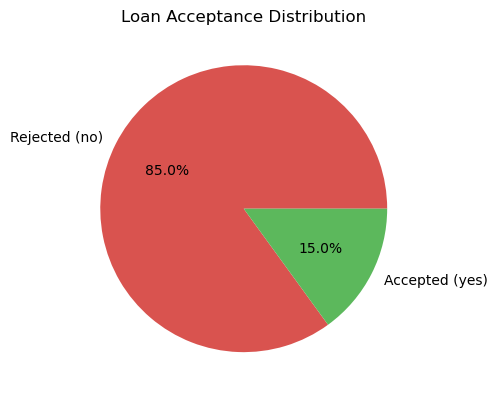

Class ratio — Rejected: 5100 | Accepted: 900
Finding: ~85% rejection rate confirms severe class imbalance.
Decision: F1-Score will be used as the primary evaluation metric throughout.


In [3]:
target_counts = df['personal_loan'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(target_counts, labels=['Rejected (no)', 'Accepted (yes)'],
        autopct='%1.1f%%', colors=['#d9534f', '#5cb85c'])
plt.title('Loan Acceptance Distribution')
plt.tight_layout()
plt.savefig('../target_proportion_pie.png', dpi=300)
plt.show()

print(f"Class ratio — Rejected: {target_counts['no']} | Accepted: {target_counts['yes']}")
print("Finding: ~85% rejection rate confirms severe class imbalance.")
print("Decision: F1-Score will be used as the primary evaluation metric throughout.")

*Observation: The dataset contains 6000 rows and 13 columns. There are missing values identified in the age, yrs_experience, family_size, and income columns.*

## 3.2 Income & Credit Card Spend by Loan Acceptance
Hypothesis 1: Customers who accept personal loans have a significantly higher
median income than those who reject. If confirmed, income is a strong predictor
and its outliers must be treated before modelling.
Hypothesis 2: Higher credit card spend correlates with loan acceptance,
suggesting active credit users are more receptive to secondary financial products.

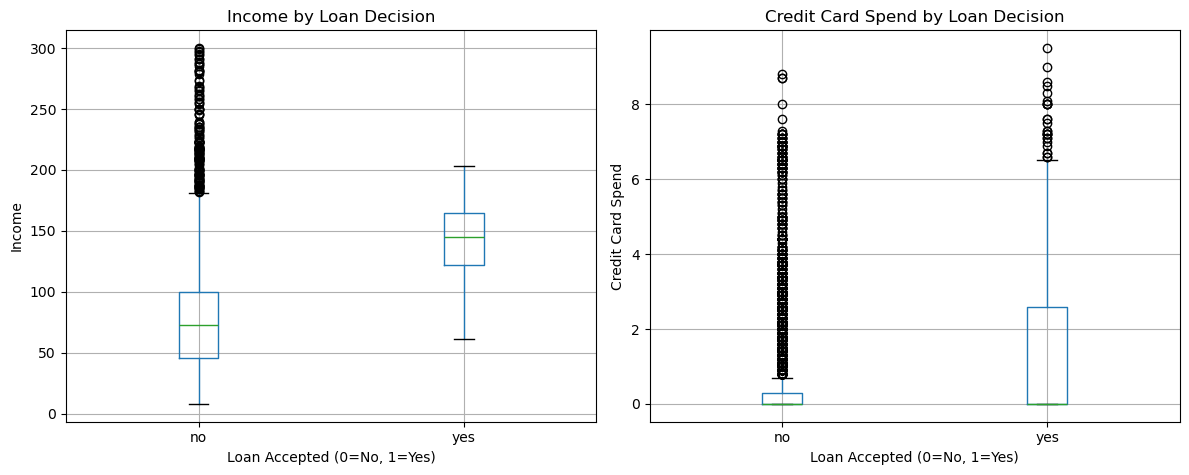

Finding 1: Acceptors show higher median income.
High-value outliers concentrated in rejected class — IQR treatment required.
Finding 2: Higher credit card spend correlates with loan acceptance.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='income', by='personal_loan', ax=ax[0])
ax[0].set_title('Income by Loan Decision')
ax[0].set_xlabel('Loan Accepted (0=No, 1=Yes)')
ax[0].set_ylabel('Income')

df.boxplot(column='credit_card_spend', by='personal_loan', ax=ax[1])
ax[1].set_title('Credit Card Spend by Loan Decision')
ax[1].set_xlabel('Loan Accepted (0=No, 1=Yes)')
ax[1].set_ylabel('Credit Card Spend')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../financial_boxplots.png', dpi=300)
plt.show()

print("Finding 1: Acceptors show higher median income.")
print("High-value outliers concentrated in rejected class — IQR treatment required.")
print("Finding 2: Higher credit card spend correlates with loan acceptance.")

## 3.3 Income Distribution Histogram
Inspects the shape of the income distribution to confirm right-skew,
which justifies median (not mean) imputation for missing income values.

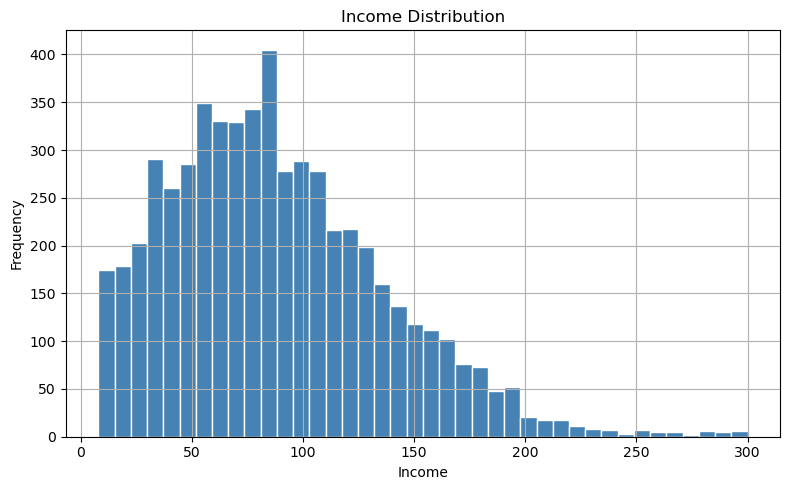

Finding: Right-skewed distribution confirms median imputation is appropriate.
Mean would be pulled upward by high earners, artificially inflating imputed values.


In [5]:
plt.figure(figsize=(8, 5))
df['income'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../income_histogram.png', dpi=300)
plt.show()

print("Finding: Right-skewed distribution confirms median imputation is appropriate.")
print("Mean would be pulled upward by high earners, artificially inflating imputed values.")

## 3.4 Correlation Heatmap
Identifies multicollinearity between continuous features and reveals which
numerical variables correlate most strongly with the target variable.
Strong correlations between predictors can cause instability in some algorithms.

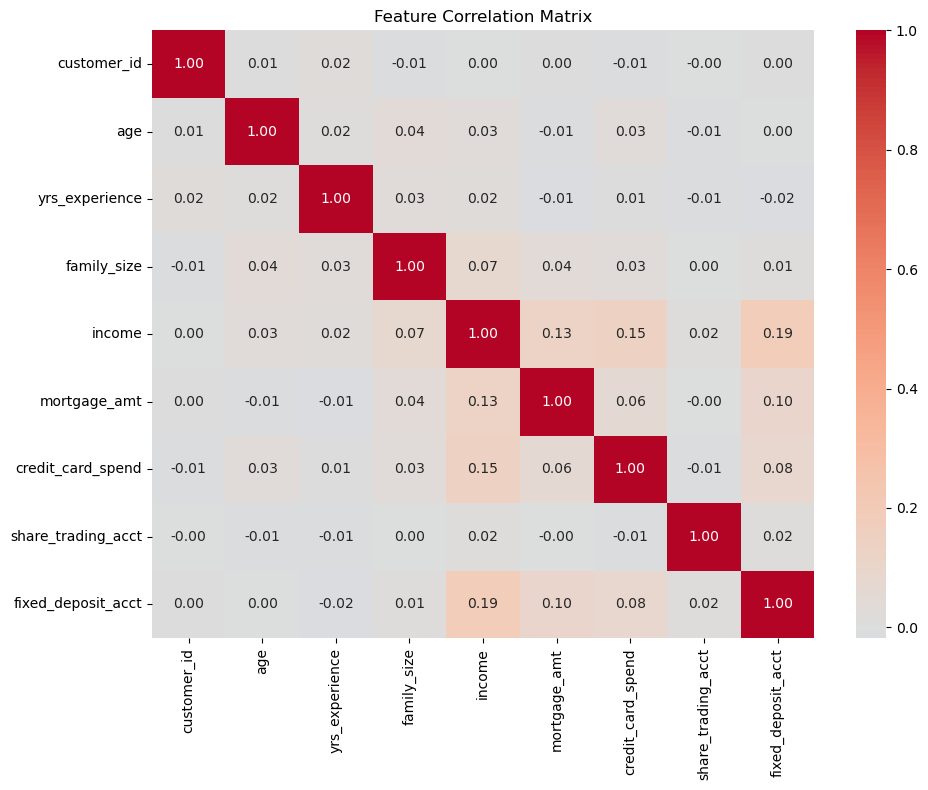

Finding: Income and mortgage_amt show moderate positive correlation with
loan acceptance. No extreme multicollinearity detected between predictors.


In [6]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../correlation_heatmap.png', dpi=300)
plt.show()

print("Finding: Income and mortgage_amt show moderate positive correlation with")
print("loan acceptance. No extreme multicollinearity detected between predictors.")

## 3.5 EDA Summary — Hypotheses & Data Quality Issues Identified
Hypotheses confirmed:
1. Income is a strong predictor: acceptors have higher median income.
2. Credit card spend is a positive signal: active credit users accept more.
3. Right-skewed income distribution: justifies median imputation over mean.
4. Severe class imbalance (~85/15): mandates F1-Score as evaluation metric.

Data quality issues to address in notebook 02:
- Missing values in: Age, Years of Experience, Family Size, Income
- Outliers confirmed in: Income, Credit Card Spend, Mortgage Amount
- Duplicates: to be checked and dropped